In [4]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import yfinance as yf

In [10]:
# Download 15 years of monthly close prices
data = yf.download(["AAPL", "KO"], period="15y", interval="1mo", auto_adjust=False)["Close"]
data = data.dropna()

data.head()
# We use monthly closing prices downloaded from yfinance, as explicitly required
# by the assignment instructions for the pair trading exercise.

[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,KO
Date,,
2011-05-01,12.422500,33.404999
2011-06-01,11.988214,33.645000
2011-07-01,13.945714,34.005001
2011-08-01,13.743929,35.224998
2011-09-01,13.618571,33.779999


"""
Data Source Justification:

Although an Excel file containing realized measures (RV and covariance) is provided,
it is not used for this analysis.

According to the assignment instructions, the pair trading strategy must be based on
15 years of monthly closing prices downloaded using the yfinance package.

Therefore, we retrieve the data directly from yfinance to ensure consistency with
the methodology required for constructing the spread and implementing the trading strategy.
"""

In [11]:
data["log_AAPL"] = np.log(data["AAPL"])
data["log_KO"] = np.log(data["KO"])
data["spread"] = data["log_AAPL"] - data["log_KO"]

data[["AAPL", "KO", "log_AAPL", "log_KO", "spread"]].head()

Ticker,AAPL,KO,log_AAPL,log_KO,spread
Date,,,,,
2011-05-01,12.422500,33.404999,2.519509,3.508706,-0.989196
2011-06-01,11.988214,33.645000,2.483924,3.515864,-1.031941
2011-07-01,13.945714,34.005001,2.635172,3.526508,-0.891335
2011-08-01,13.743929,35.224998,2.620597,3.561756,-0.941159
2011-09-01,13.618571,33.779999,2.611434,3.519869,-0.908434


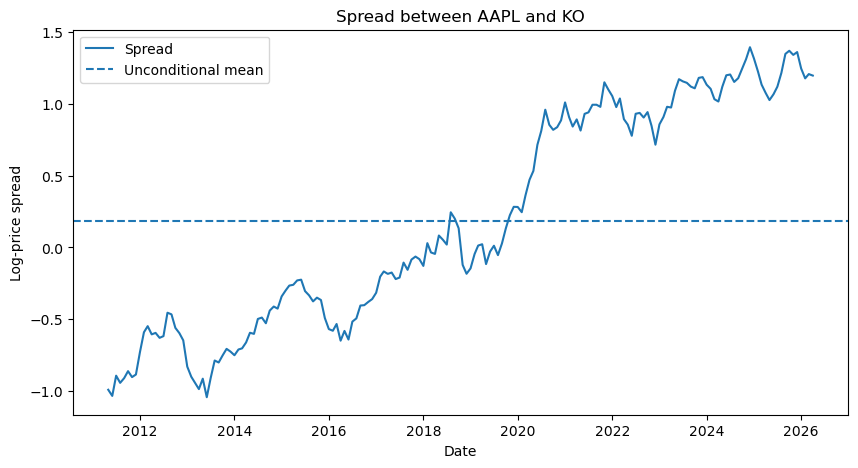

In [12]:
spread_mean = data["spread"].mean()

plt.figure(figsize=(10, 5))
plt.plot(data.index, data["spread"], label="Spread")
plt.axhline(spread_mean, linestyle="--", label="Unconditional mean")
plt.title("Spread between AAPL and KO")
plt.xlabel("Date")
plt.ylabel("Log-price spread")
plt.legend()
plt.show()

In [13]:
# The spread shows a clear upward trend rather than fluctuating around a stable mean.
# This suggests that the relationship between AAPL and KO is not stable over time.
# As a result, the spread does not appear to be mean-reverting, which challenges
# the core assumption behind pairs trading strategies.

Pour l'oral:
"“We observe that the spread is trending upward, which suggests that the two assets do not share a stable long-term relationship. This weakens the validity of a mean-reversion trading strategy.”"

<Figure size 800x400 with 0 Axes>

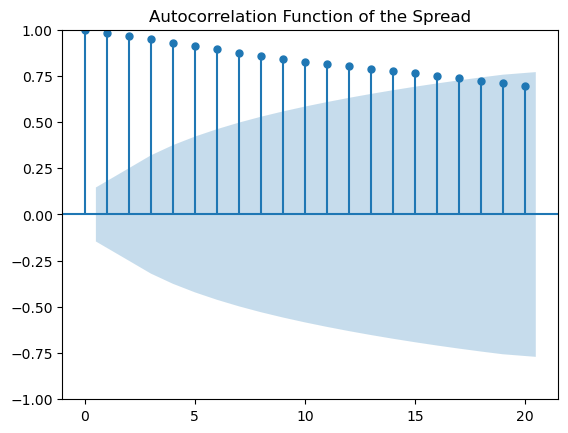

In [14]:
# ACF of Spread
plt.figure(figsize=(8, 4))
plot_acf(data["spread"], lags=20)
plt.title("Autocorrelation Function of the Spread")
plt.show()

In [15]:
# The ACF shows strong and persistent autocorrelation, indicating that the spread
# does not quickly return to its mean. This weakens the evidence for mean reversion.

Pour l'oral : 
"The ACF shows very strong persistence, which suggests that the spread is not mean-reverting.”

In [16]:
# Couper l’échantillon en deux

#La première moitié sert à démarrer l’historique, la deuxième à trader out-of-sample.

n = len(data)
split = n // 2

data["position_AAPL"] = 0
data["position_KO"] = 0
data["mu_t"] = np.nan
data["sigma_t"] = np.nan

In [17]:
current_position = 0  # 1 = AAPL, -1 = KO, 0 = cash

for t in range(split, n):
    
    hist_spread = data["spread"].iloc[:t]
    mu_t = hist_spread.mean()
    sigma_t = hist_spread.std()
    s_t = data["spread"].iloc[t]

    data.loc[data.index[t], "mu_t"] = mu_t
    data.loc[data.index[t], "sigma_t"] = sigma_t

    # ENTRY rules
    if current_position == 0:
        if s_t < mu_t - sigma_t:
            current_position = 1   # buy AAPL
        elif s_t > mu_t + sigma_t:
            current_position = -1  # buy KO

    # EXIT rules
    elif current_position == 1:
        if s_t >= mu_t:
            current_position = 0

    elif current_position == -1:
        if s_t <= mu_t:
            current_position = 0

    # store positions
    data.loc[data.index[t], "position_AAPL"] = 1 if current_position == 1 else 0
    data.loc[data.index[t], "position_KO"] = 1 if current_position == -1 else 0

In [18]:
# We implement an out-of-sample trading strategy.
# At each time t, we compute the historical mean and standard deviation of the spread
# using only past information. Trading decisions are then based on deviations of the
# spread from its historical average.

In [19]:
# Returns
data["ret_AAPL"] = data["AAPL"].pct_change()
data["ret_KO"] = data["KO"].pct_change()

# Lead returns (t+1)
data["ret_AAPL_lead"] = data["ret_AAPL"].shift(-1)
data["ret_KO_lead"] = data["ret_KO"].shift(-1)

data = data.dropna()

In [24]:
# Returns
data["ret_AAPL"] = data["AAPL"].pct_change()
data["ret_KO"] = data["KO"].pct_change()

# Lead returns (t+1)
data["ret_AAPL_lead"] = data["ret_AAPL"].shift(-1)
data["ret_KO_lead"] = data["ret_KO"].shift(-1)

# Remove NaN created by pct_change and shift
data = data.dropna().copy()

# Recompute sample size and split AFTER dropna
n = len(data)
split = n // 2

print("n =", n)
print("split =", split)
print("rows in second half =", len(data.iloc[split:]))

n = 43
split = 21
rows in second half = 22


In [25]:
# Initialize trading variables
data["position_AAPL"] = 0
data["position_KO"] = 0
data["mu_t"] = np.nan
data["sigma_t"] = np.nan

In [26]:
current_position = 0  # 1 = hold AAPL, -1 = hold KO, 0 = cash

for t in range(split, n):
    hist_spread = data["spread"].iloc[:t]
    mu_t = hist_spread.mean()
    sigma_t = hist_spread.std()
    s_t = data["spread"].iloc[t]

    data.loc[data.index[t], "mu_t"] = mu_t
    data.loc[data.index[t], "sigma_t"] = sigma_t

    if current_position == 0:
        if s_t < mu_t - sigma_t:
            current_position = 1
        elif s_t > mu_t + sigma_t:
            current_position = -1

    elif current_position == 1:
        if s_t >= mu_t:
            current_position = 0

    elif current_position == -1:
        if s_t <= mu_t:
            current_position = 0

    data.loc[data.index[t], "position_AAPL"] = 1 if current_position == 1 else 0
    data.loc[data.index[t], "position_KO"] = 1 if current_position == -1 else 0

In [27]:
import statsmodels.api as sm

reg = data.iloc[split:].copy()

# AAPL regression
X1 = sm.add_constant(reg["position_AAPL"])
y1 = reg["ret_AAPL_lead"]

model1 = sm.OLS(y1, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          ret_AAPL_lead   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 02 Apr 2026   Prob (F-statistic):                nan
Time:                        16:54:24   Log-Likelihood:                 31.530
No. Observations:                  22   AIC:                            -61.06
Df Residuals:                      21   BIC:                            -59.97
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0218      0.013      1.729

C:\Users\mathi\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [28]:
print(reg["position_AAPL"].value_counts())
print(reg["position_KO"].value_counts())

position_AAPL
0    22
Name: count, dtype: int64
position_KO
1    15
0     7
Name: count, dtype: int64


In [29]:
print(reg[["spread", "mu_t", "sigma_t", "position_AAPL", "position_KO"]].tail(10))

Ticker        spread      mu_t   sigma_t  position_AAPL  position_KO
Date                                                                
2025-04-01  1.074666  1.086526  0.151244              0            0
2025-05-01  1.024504  1.086177  0.148948              0            0
2025-06-01  1.064686  1.084415  0.147112              0            0
2025-07-01  1.117580  1.083867  0.145032              0            0
2025-08-01  1.213379  1.084778  0.143111              0            0
2025-09-01  1.345320  1.088162  0.142697              0            1
2025-10-01  1.367135  1.094756  0.146704              0            1
2025-11-01  1.338572  1.101565  0.151080              0            1
2025-12-01  1.358078  1.107346  0.153703              0            1
2026-01-01  1.243728  1.113316  0.156669              0            1


In [30]:
# The trading rule generates no buy signals for AAPL in the out-of-sample period,
# since the spread never falls sufficiently below its historical mean.
# In contrast, the strategy frequently takes positions in KO, because the spread
# remains persistently above the upper threshold.
# This asymmetry is consistent with the upward-trending spread observed earlier.

In [31]:
# KO regression
X2 = sm.add_constant(reg["position_KO"])
y2 = reg["ret_KO_lead"]

model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            ret_KO_lead   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     2.024
Date:                Thu, 02 Apr 2026   Prob (F-statistic):              0.170
Time:                        16:56:58   Log-Likelihood:                 35.766
No. Observations:                  22   AIC:                            -67.53
Df Residuals:                      20   BIC:                            -65.35
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0082      0.019     -0.436      

In [32]:
# The coefficient on the KO dummy is positive, suggesting that the strategy tends
# to hold KO before periods of slightly higher returns. However, the coefficient
# is not statistically significant (p-value = 0.170), meaning that this result is
# not robust. Therefore, we cannot conclude that the trading strategy has predictive power.

Pour l'oral:
"Although the coefficient is positive, it is not statistically significant, so the strategy does not reliably predict returns.”

In [34]:
# Strategy returns
data["strategy_ret_gross"] = (
    data["position_AAPL"] * data["ret_AAPL_lead"] +
    data["position_KO"] * data["ret_KO_lead"]
)

trading_data = data.iloc[split:].copy()

# Capital without transaction costs
trading_data["capital_gross"] = 100 * (1 + trading_data["strategy_ret_gross"]).cumprod()

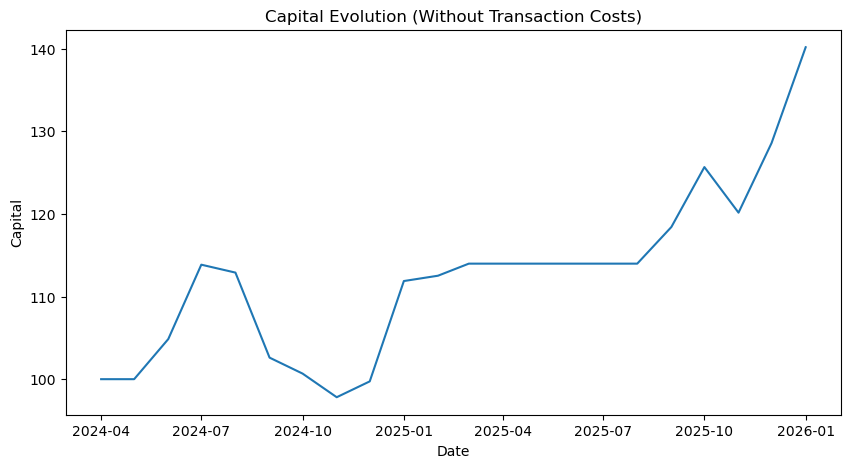

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(trading_data.index, trading_data["capital_gross"])
plt.title("Capital Evolution (Without Transaction Costs)")
plt.xlabel("Date")
plt.ylabel("Capital")
plt.show()

In [36]:
# The capital appears to increase over time, suggesting that the strategy
# may generate profits. However, this result should be interpreted with caution.
# The regression results showed no statistical significance, and the sample size
# is relatively small. Therefore, the observed performance may be driven by chance
# rather than a reliable trading signal.

In [37]:
# Transaction costs
trading_data["state"] = trading_data["position_AAPL"] - trading_data["position_KO"]
trading_data["trade_change"] = trading_data["state"].diff().abs().fillna(abs(trading_data["state"]))

cost = 0.005

trading_data["strategy_ret_net"] = (
    trading_data["strategy_ret_gross"] - cost * trading_data["trade_change"]
)

trading_data["capital_net"] = 100 * (1 + trading_data["strategy_ret_net"]).cumprod()

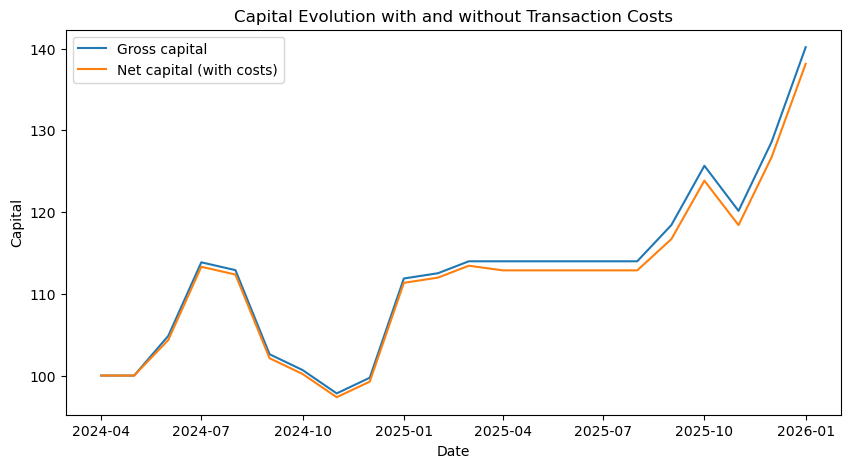

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(trading_data.index, trading_data["capital_gross"], label="Gross capital")
plt.plot(trading_data.index, trading_data["capital_net"], label="Net capital (with costs)")
plt.title("Capital Evolution with and without Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Capital")
plt.legend()
plt.show()